# Red or Blue Who Wins?

**Name(s)**: Shriya Pattapu, Milo Palmquist

**Website Link**: https://spattapu1.github.io/LoL-Statistical-Analysis/

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn as sk
from scipy import stats

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.

In professional play does the side of the map you are on affect your win rate? -> Sample from data this diff in wins from blue and red in samples (perm tes) -> (two tail)
classify a team or blue side based on other features.

## Step 1: Introduction

## Step 2: Data Cleaning and Exploratory Data Analysis

In [53]:
df = pd.read_csv("main.csv")

/var/folders/ct/mkdcx0p53gqgmfvf541_sql40000gn/T/ipykernel_6331/3455604807.py:1: DtypeWarning:

Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.



In [54]:
complete = df[df['datacompleteness'] == 'complete']

In [55]:
players = complete[complete['position'] != 'team'][['gameid', 'league', 'side', 'position','teamname','result','kills','deaths','assists', 'earnedgold', 'damagetochampions', 'total cs']]

In [56]:
players.head()

,gameid,league,side,position,...,assists,earnedgold,damagetochampions,total cs
0,ESPORTSTMNT01_2690210,LCKC,Blue,top,...,2,7164.0,15768.0,231.0
1,ESPORTSTMNT01_2690210,LCKC,Blue,jng,...,6,5368.0,11765.0,148.0
2,ESPORTSTMNT01_2690210,LCKC,Blue,mid,...,3,5945.0,14258.0,193.0
3,ESPORTSTMNT01_2690210,LCKC,Blue,bot,...,2,6835.0,11106.0,226.0
4,ESPORTSTMNT01_2690210,LCKC,Blue,sup,...,6,2908.0,3663.0,42.0


In [57]:
teams = complete[complete['position'] == 'team'][['gameid','league','side','teamname','result', 'teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']]

In [58]:
teams.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [7]:
win_rates_per_side = (teams[teams['result'] == 1].groupby('side').size() / teams.groupby('side').size()).to_frame().reset_index()

fig = px.bar(win_rates_per_side, x = 'side', y = 0, color='side', title = 'Win Rate Per Side', 
             color_discrete_map={'Blue': 'blue', 'Red': 'red'},)
fig.update_layout(yaxis_title="Win Rate")
fig

In [8]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total kills")
fig.update_layout(title="Total Kills by Side")

In [9]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.75)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total earned gold")
fig.update_layout(title="Total Earned Gold by Side")

In [10]:
def foo(x):
    
players.groupby('gameid').filter(foo)

IndentationError: expected an indented block after function definition on line 1 (3418709582.py, line 3)

In [11]:
# TODO

## Step 3: Assessment of Missingness

In [12]:
# TODO

## Step 4: Hypothesis Testing

In [13]:
teams.head()

,gameid,league,side,teamname,...,teamdeaths,assists,earnedgold,damagetochampions
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,19,19,28222.0,56560.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,9,62,33769.0,79912.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,16,7,34688.0,59579.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,3,39,48063.0,74855.0
34,8401-8401_game_1,LPL,Blue,Oh My God,...,6,35,30167.0,40086.0


In [14]:
sampling_dist = []
for i in range(1000):
    sample = teams.sample(2500)
    by_side = sample.groupby('side')['teamkills'].mean()
    sampling_dist.append(by_side['Blue'] - by_side['Red'])

sampling_dist = pd.DataFrame(sampling_dist, columns=["Difference in Means of Team Kills (Blue - Red)"])

In [15]:
sampling_dist

,Difference in Means of Team Kills (Blue - Red)
0,0.89
1,0.46
2,0.75
...,...
997,0.42
998,0.23
999,0.58


In [16]:
hist = px.histogram(sampling_dist)

In [17]:
t_stat, p_val = stats.ttest_1samp(sampling_dist, 0)
t_stat, p_val

(array([62.03]), array([0.]))

## Step 5: Framing a Prediction Problem

In [20]:
teams['side'] = teams['side'].map({'Blue': 0, 'Red': 1})

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(teams[['teamkills', 'earnedgold']], teams['side'], random_state=1)
)

In [23]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, criterion='entropy')
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

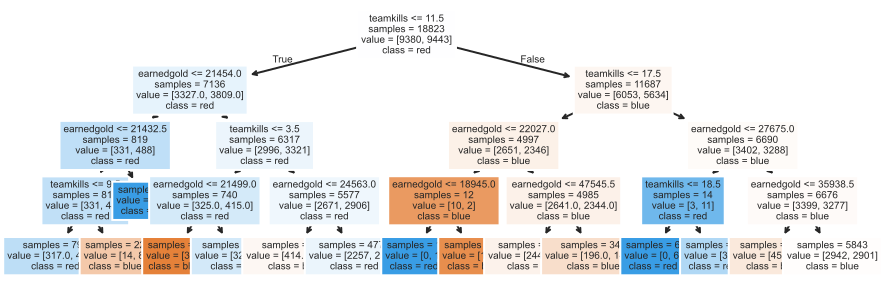

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 5))
plot_tree(dt, feature_names=X_train.columns, class_names=['blue', 'red'], 
          filled=True, fontsize=10, impurity=False);

In [28]:
win_rates_per_side = (teams[teams['result'] == 1].groupby('side').size() / teams.groupby('side').size()).to_frame().reset_index()

fig = px.bar(win_rates_per_side, x = 'side', y = 0, color='side', title = 'Win Rate Per Side', 
             color_discrete_map={'Blue': 'blue', 'Red': 'red'},)
fig.update_layout(yaxis_title="Win Rate")

In [29]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total kills")
fig.update_layout(title="Total Kills by Side")

In [31]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.75)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="total earned gold")
fig.update_layout(title="Total Earned Gold by Side")

In [18]:
# TODO

## Step 6: Baseline Model

In [59]:
teams.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
10,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
11,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
22,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
23,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
46,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [60]:
teams.columns

Index(['gameid', 'league', 'side', 'teamname', 'result', 'teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons'],
      dtype='object')

In [61]:
winners = teams[teams['result'] == 1][['gameid', 'side']]
winners.head()

,gameid,side
11,ESPORTSTMNT01_2690210,Red
23,ESPORTSTMNT01_2690219,Red
46,ESPORTSTMNT01_2690227,Blue
71,ESPORTSTMNT01_2690255,Red
94,ESPORTSTMNT01_2690264,Blue


In [62]:
unique_games = teams['gameid'].unique()

cols = ['teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons']

games_dict = {}
for game in unique_games:
    temp = teams[teams['gameid'] == game]
    
    diffs = []
    for col in cols:
        diff = -1 * (temp[col].diff().iloc[1])
        diffs.append(diff)
    
    games_dict[game] = diffs
    

In [63]:
diffs_df = pd.DataFrame(games_dict).T
diffs_df.columns = cols
diffs_df = diffs_df.merge(winners, how='inner', left_index=True, right_on='gameid')
diffs_df = diffs_df.set_index('gameid')
diffs_df = diffs_df.rename(columns={'side': 'winner'})
diffs_df

,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons,winner
gameid,,,,,,,,
ESPORTSTMNT01_2690210,-10.0,-5547.0,-23352.0,-3971.0,-97.0,-2.0,-0.0,Red
ESPORTSTMNT01_2690219,-13.0,-13375.0,-15276.0,-7746.0,-33.0,-3.0,-2.0,Red
ESPORTSTMNT01_2690227,9.0,10691.0,21256.0,2532.0,5.0,3.0,1.0,Blue
...,...,...,...,...,...,...,...,...
ESPORTSTMNT01_3268686,-16.0,-10325.0,-22161.0,5476.0,129.0,-2.0,-1.0,Red
ESPORTSTMNT01_3269631,10.0,8771.0,2804.0,-899.0,-48.0,-1.0,-0.0,Blue
ESPORTSTMNT01_3268705,13.0,15074.0,33121.0,2143.0,30.0,4.0,1.0,Blue


## Step 7: Final Model

In [ ]:
# TODO

## Step 8: Fairness Analysis

In [ ]:
# TODO